In [22]:
import sys
sys.path.append("src")

import numpy as np
from detection import bandpass_filter, combined_signal, detect_spikes

npx_path = "data/raw/c37_npx_raw.bin"
npx_channels = 384
npx_samples = 4050171
fs = 30000

npx_recording = np.memmap(npx_path, mode='r', dtype=np.int16, order='C')
npx_recording = npx_recording.reshape((npx_channels, npx_samples), order='F')

ground_truth_spikes = np.load("data/raw/c37_extracellular_spikes.npy")
print(f"Recording shape: {npx_recording.shape}")
print(f"Ground truth spikes: {len(ground_truth_spikes)}")

Recording shape: (384, 4050171)
Ground truth spikes: 601


In [23]:
channels_subset = list(range(180, 220))
subset_data = npx_recording[channels_subset, :].T.astype(np.float32)

filtered = bandpass_filter(subset_data, fs)
print(f"Filtered shape: {filtered.shape}")

Filtered shape: (4050171, 40)


Task was destroyed but it is pending!
task: <Task pending name='Task-229' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/rishirajmanna/Desktop/pulse-sort/venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-230' coro=<Kernel.shell_main() running at /Users/rishirajmanna/Desktop/pulse-sort/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/rishirajmanna/Desktop/pulse-sort/venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/rishirajmanna/Desktop/pulse-sort/venv/lib/python3.13/site-packages/matplotlib/_api/__init__.py:214: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for key, val in kwargs.items():
Task was destroyed but it is pending!
task: <Task pending name='Task-230' coro=<Kernel.shell_main() running at /Users/rishirajmanna/Desktop/pulse-sort/venv/lib/python3.13/site-packages/ipykerne

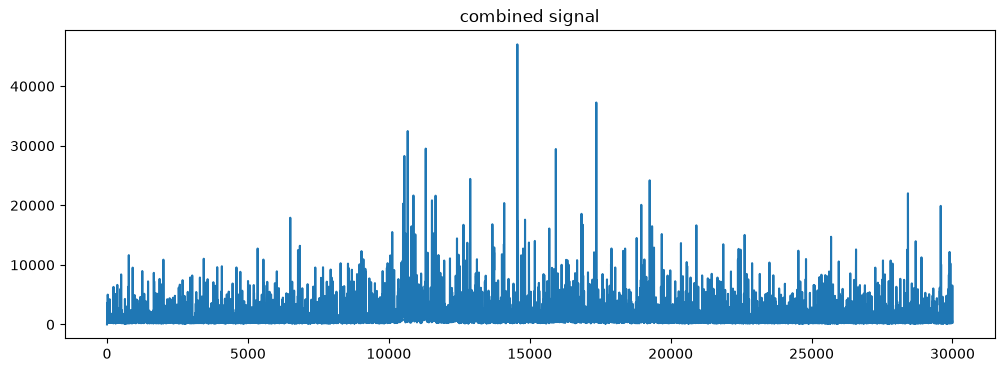

In [24]:
import matplotlib.pyplot as plt

combo = combined_signal(filtered, method="sum_sq")

plt.figure(figsize=(12, 4))
plt.plot(combo[:fs])
plt.title("combined signal")
plt.savefig("figures/combined_signal.png")
plt.show()

In [25]:
detected_spike_times = detect_spikes(combo, fs)
print(f"Detected {len(detected_spike_times)} spikes")

Detected 2685 spikes


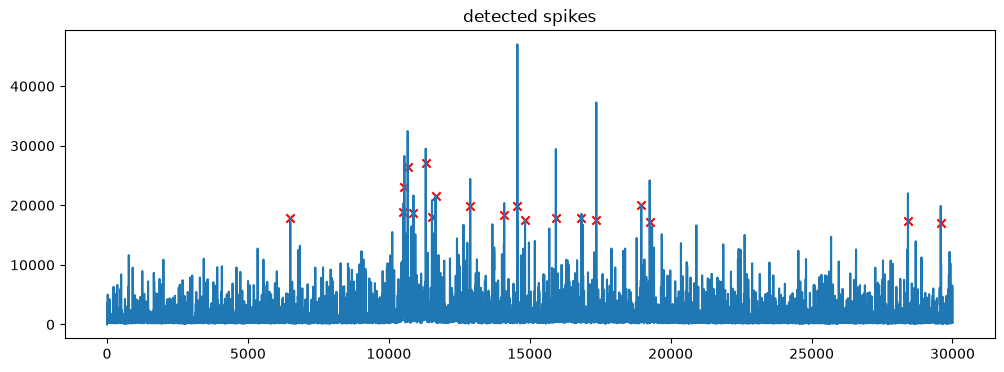

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(combo[:fs])
spikes_in_window = detected_spike_times[detected_spike_times < fs]
plt.scatter(spikes_in_window, combo[spikes_in_window], color='red', marker='x')
plt.title("detected spikes")
plt.savefig("figures/detected_spikes.png")
plt.show()

In [28]:
tolerance_samples = int(0.001 * fs)

detected_matched = np.zeros(len(detected_spike_times), dtype=bool)
true_matched = np.zeros(len(ground_truth_spikes), dtype=bool)

for i, t in enumerate(detected_spike_times):
    diffs = np.abs(ground_truth_spikes - t)
    close = diffs <= tolerance_samples
    if np.any(close):
        detected_matched[i] = True
        true_matched[close] = True

precision = detected_matched.sum() / len(detected_spike_times) * 100
recall = true_matched.sum() / len(ground_truth_spikes) * 100

print(f"Precision: {detected_matched.sum()} / {len(detected_spike_times)} ({precision:.1f}%)")
print(f"Recall: found {true_matched.sum()} / {len(ground_truth_spikes)} ({recall:.1f}%)")

Precision: 363 / 2685 (13.5%)
Recall: found 360 / 601 (59.9%)
